# Stage 8 — Model training

_Pipeline stage 8 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Training the CNN + combined XGBoost (per regime)

Two models per regime. **OutletCNN** (a small ~24k-parameter conv net) encodes the
5-class patch into a 4-D embedding, trained with **Taiwan held out** for an honest
leave-one-basin test. The **combined XGBoost** then classifies on the 5 dimensionless
features **+** the 4 CNN embeddings (9 features), split by `GroupShuffleSplit` on
`basin__outlet` so no outlet leaks across train/test. We inspect convergence, what the
embedding learned, feature importance, and the model-comparison table.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
from channel_heads.models.cnn import OutletCNN, DEFAULT_EMBEDDING_DIM
from channel_heads.rasterization.schema import NUM_CLASSES
net = OutletCNN(in_channels=NUM_CLASSES, embedding_dim=DEFAULT_EMBEDDING_DIM)
print(f'OutletCNN: {sum(p.numel() for p in net.parameters()):,} params | '
      f'{NUM_CLASSES}-channel input -> {DEFAULT_EMBEDDING_DIM}-D embedding -> logit')

OutletCNN: 24,361 params | 5-channel input -> 4-D embedding -> logit


### 1 · CNN convergence (per-regime loss curves)

regA: best val_loss 0.7208 @ epoch 39 / 51 epochs
regB: best val_loss 0.7022 @ epoch 57 / 60 epochs
regC: best val_loss 0.6924 @ epoch 30 / 42 epochs


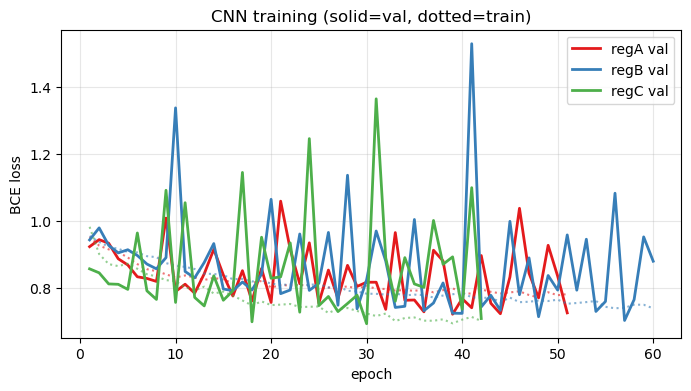

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for r in REGIMES_:
    h = MODELS / f'cnn_outlet_{r}_history.csv'
    if h.exists():
        hist = pd.read_csv(h)
        ax.plot(hist.epoch, hist.val_loss, color=RC[r], lw=2, label=f'{r} val')
        ax.plot(hist.epoch, hist.train_loss, color=RC[r], ls=':', alpha=0.6)
        print(f'{r}: best val_loss {hist.val_loss.min():.4f} @ epoch {int(hist.val_loss.idxmin())+1} / {len(hist)} epochs')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss'); ax.set_title('CNN training (solid=val, dotted=train)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

### 2 · What the embedding learned (all 4 dims, by class)

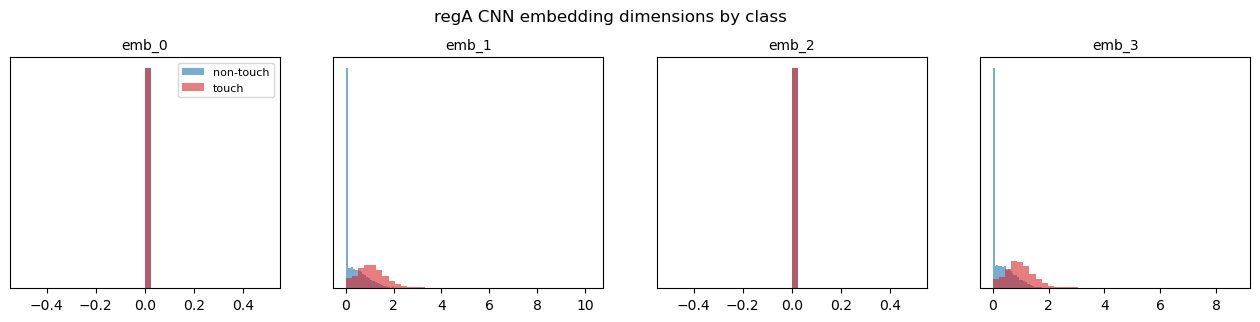

In [4]:
d = pd.read_csv(RESULTS_DIR / 'master_dataset_regA_with_emb.csv')
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, ax in enumerate(axes):
    for lbl, col, nm in [(0, '#1f77b4', 'non-touch'), (1, '#d62728', 'touch')]:
        v = d.loc[d.y == lbl, f'emb_{i}'].dropna()
        ax.hist(v, bins=40, alpha=0.6, color=col, density=True, label=nm)
    ax.set_title(f'emb_{i}', fontsize=10); ax.set_yticks([])
axes[0].legend(fontsize=8); plt.suptitle('regA CNN embedding dimensions by class', y=1.04); plt.show()

### 3 · XGBoost feature importance (geom vs CNN contribution)

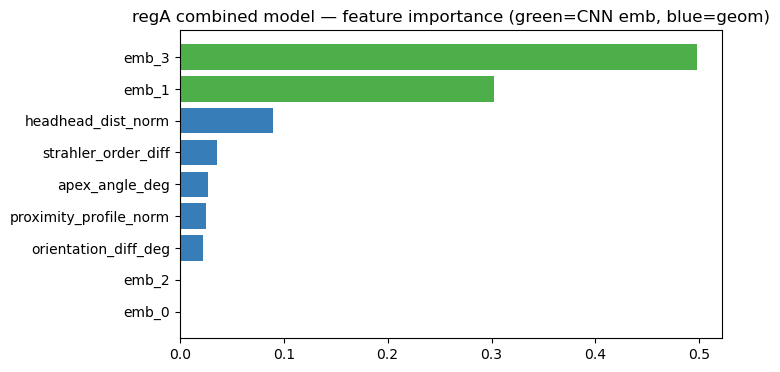

In [5]:
from xgboost import XGBClassifier
feats = MODEL_FEATURES + [f'emb_{i}' for i in range(4)]
mdl = XGBClassifier(); mdl.load_model(str(MODELS / 'xgb_geom_plus_cnn_emb_regA.json'))
imp = pd.Series(mdl.feature_importances_, index=feats).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, color=['#4daf4a' if f.startswith('emb') else '#377eb8' for f in imp.index])
ax.set_title('regA combined model — feature importance (green=CNN emb, blue=geom)'); plt.show()

### 4 · Model-comparison table (geom-only vs geom+CNN per regime)

In [6]:
p = MODELS / 'ALL_MODELS_METRICS.csv'
pd.read_csv(p) if p.exists() else 'train models first'

,model,n_feat,roc_auc,pr_auc,thr,P,R,F1,Acc
0,baseline geom_only,5,0.7474,0.7055,0.5953,0.6533,0.5034,0.5687,0.6855
1,baseline geom+cnn_emb,9,0.9103,0.8784,0.8420,0.9068,0.5000,0.6446,0.7729
2,baseline geom+cnn_logit,6,0.9110,0.8788,0.8331,0.9176,0.5342,0.6753,0.7884
3,regA geom_only,5,0.7652,0.6256,0.5803,0.5560,0.5000,0.5265,0.7435
4,regA geom+cnn_emb,9,0.8827,0.7557,0.7563,0.7537,0.5023,0.6028,0.8112
5,regB geom_only,5,0.7109,0.5725,0.5355,0.4913,0.5000,0.4956,0.6774
6,regB geom+cnn_emb,9,0.8814,0.7748,0.7793,0.7788,0.5039,0.6119,0.7974
7,regC geom_only,5,0.7956,0.6470,0.5897,0.5962,0.5029,0.5456,0.7818
8,regC geom+cnn_emb,9,0.8841,0.7644,0.7594,0.7921,0.5007,0.6136,0.8357


**Takeaway.** All three CNNs converge cleanly (val loss plateaus, early stopping).
The embedding dimensions are clearly class-separated, and the combined model leans on
both geometry and CNN features — adding the embedding lifts ROC-AUC by ~0.09–0.17 over
geometry alone per regime. The patch *shape* carries real, complementary signal beyond
the 5 scalars.